In [1]:
# Import all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np
%matplotlib inline

In [2]:
# Start with the mutagenicity dataset
df = pd.read_csv('../data/mutagenicity_kNN.csv')
df.head()

,Unnamed: 0,Id,CAS,SMILES,Status,Experimental value,Predicted value,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,0,1,100-00-5,O=[N+]([O-])c1ccc(cc1)Cl,Training,1,1,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.2482
1,1,2,100-01-6,O=[N+]([O-])c1ccc(N)cc1,Training,1,1,52,0.359544,69.16,37.5088,3.003401,242.429658,138.126,1.1770
2,2,3,100-02-7,O=[N+]([O-])c1ccc(O)cc1,Training,0,1,52,0.470728,63.37,34.7612,3.003401,241.674771,139.110,1.3004
3,3,4,100-11-8,O=[N+]([O-])c1ccc(cc1)CBr,Training,1,0,58,0.432586,43.14,45.7274,2.913802,257.648013,216.034,2.4897
4,4,5,100-12-9,O=[N+]([O-])c1ccc(cc1)CC,Training,0,0,58,0.479785,43.14,42.4744,2.913802,253.299498,151.165,2.1572


In [3]:
# Column names
df.columns.to_list()

['Unnamed: 0',
 'Id',
 'CAS',
 'SMILES',
 'Status',
 'Experimental value',
 'Predicted value',
 'NumValenceElectrons',
 'qed',
 'TPSA',
 'MolMR',
 'BalabanJ',
 'BertzCT',
 'MolWt',
 'MolLogP']

In [4]:
# Check for null values
df.isnull().sum()

Unnamed: 0             0
Id                     0
CAS                    0
SMILES                 0
Status                 0
Experimental value     0
Predicted value        0
NumValenceElectrons    0
qed                    0
TPSA                   0
MolMR                  0
BalabanJ               0
BertzCT                0
MolWt                  0
MolLogP                0
dtype: int64

In [5]:
#Check for data types
df.dtypes

Unnamed: 0               int64
Id                       int64
CAS                        str
SMILES                     str
Status                     str
Experimental value       int64
Predicted value            str
NumValenceElectrons      int64
qed                    float64
TPSA                   float64
MolMR                  float64
BalabanJ               float64
BertzCT                float64
MolWt                  float64
MolLogP                float64
dtype: object

In [6]:
df['Predicted value'].value_counts()

Predicted value
1                3309
0                2449
Non Predicted       6
Name: count, dtype: int64

In [7]:
df["Experimental value"].value_counts()

Experimental value
1    3251
0    2513
Name: count, dtype: int64

In [8]:
df.shape

(5764, 15)

In [9]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
# data cleanup. There are 6 non predicted values in the dataset. We will remove them from the dataset.
non_predicted = df[(df['Predicted value'] != '0') & (df['Predicted value'] != '1')].index
clean_df = df.drop(non_predicted, axis=0)
clean_df.dtypes

Unnamed: 0               int64
Id                       int64
CAS                        str
SMILES                     str
Status                     str
Experimental value       int64
Predicted value            str
NumValenceElectrons      int64
qed                    float64
TPSA                   float64
MolMR                  float64
BalabanJ               float64
BertzCT                float64
MolWt                  float64
MolLogP                float64
dtype: object

In [11]:
# Collect the input features and remove the unwanted ones from the dataset.

X = clean_df.drop(['Unnamed: 0', 'Id','CAS','SMILES','Status','Experimental value','Predicted value'],axis=1)
X.columns.to_list()

['NumValenceElectrons',
 'qed',
 'TPSA',
 'MolMR',
 'BalabanJ',
 'BertzCT',
 'MolWt',
 'MolLogP']

In [12]:
# make y
y = clean_df['Experimental value']


In [13]:
y.value_counts(normalize=True)*100

Experimental value
1    56.425842
0    43.574158
Name: proportion, dtype: float64

Y values are fairly balanced. the X valued need to standardized.

In [14]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
NumValenceElectrons,5758.0,87.031087,42.603017,10.000000,60.000000,82.000000,104.000000,490.000000
qed,5758.0,0.514139,0.165875,0.016502,0.401795,0.513585,0.626246,0.924384
TPSA,5758.0,53.816429,43.054712,0.000000,26.020000,46.170000,72.435000,633.360000
MolMR,5758.0,65.092698,30.781928,3.929500,43.279900,62.225800,81.762675,328.444600
BalabanJ,5758.0,2.573690,0.641105,0.854053,2.130968,2.480737,2.953223,6.947594
BertzCT,5758.0,520.670843,378.010345,0.000000,228.372017,460.689080,748.421726,5033.685325
MolWt,5758.0,241.254551,116.073192,28.010000,165.192000,228.247000,290.811750,1550.188000
MolLogP,5758.0,2.586324,1.939714,-13.262400,1.342250,2.466700,3.752295,17.853900


In [15]:
# How many molecules in our dataset have a qed less than 0.5?
X[X.qed < 0.5].shape[0] / X.shape[0] * 100

46.405001736714134

In [16]:
# What is the molecule with the largest molecular weight MolWt?
# Entire dataset is used as we already seperated some features to get X and X did not include the name of the molecule.
clean_df.loc[clean_df.MolWt.idxmax()] #idxmax() returns the index of the maximum value in the column MolWt. 

Unnamed: 0                                                          5220
Id                                                                  5228
CAS                                                           92339-11-2
SMILES                 O=C(NCC(O)CO)c1c(c(C(=O)NCC(O)CO)c(c(c1I)N(C(=...
Status                                                          Training
Experimental value                                                     0
Predicted value                                                        0
NumValenceElectrons                                                  346
qed                                                             0.059189
TPSA                                                              339.09
MolMR                                                             272.95
BalabanJ                                                        2.841564
BertzCT                                                       1756.23998
MolWt                                              

In [17]:
# What is the average number of valance electrons NumValenceElectrons of the molecules in our dataset?
X.NumValenceElectrons.mean()

np.float64(87.03108718304966)

In [18]:
# Splitting the data into training and testing sets. We will use 80% of the data for training and 20% for testing.
from sklearn.model_selection import train_test_split

X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4606, 8), (1152, 8), (4606,), (1152,))

In [19]:
y_train.value_counts(normalize=True)*100

Experimental value
1    56.491533
0    43.508467
Name: proportion, dtype: float64

In [20]:
y_test.value_counts(normalize=True)*100

Experimental value
1    56.163194
0    43.836806
Name: proportion, dtype: float64

In [21]:
# Feature scaling is important for KNN as it is a distance based algorithm. We will use StandardScaler to scale the features.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
X_train_scaled

array([[ 0.21156339, -0.30165844,  0.37123656, ..., -0.077431  ,
         0.07950634, -0.36776223],
       [ 0.30488246, -1.8256133 , -0.24865881, ...,  1.31910646,
         0.277756  ,  1.28767139],
       [ 0.63149918, -0.42673591,  1.05421967, ...,  1.29057823,
         0.6043547 ,  0.38809475],
       ...,
       [ 0.67815871,  0.78697054,  1.81127245, ...,  0.77197679,
         0.87202314, -0.37166006],
       [-0.20837239,  1.16748347,  0.22286357, ..., -0.85961555,
        -0.02907882, -0.69027163],
       [-0.90826537,  0.65982173, -0.78396989, ..., -0.78159188,
        -0.67118538,  0.06027012]], shape=(4606, 8))

In [23]:
# kNN MOdel 
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [24]:
# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
accuracy = accuracy_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
roc_auc = roc_auc_score(y_test, y_pred_knn)
print(f"Accuracy: {accuracy:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"ROC AUC: {roc_auc:.3f}")


Accuracy: 0.699
F1 Score: 0.738
Precision: 0.722
Recall: 0.754
ROC AUC: 0.691


In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
cm

array([[317, 188],
       [159, 488]])

<Axes: >

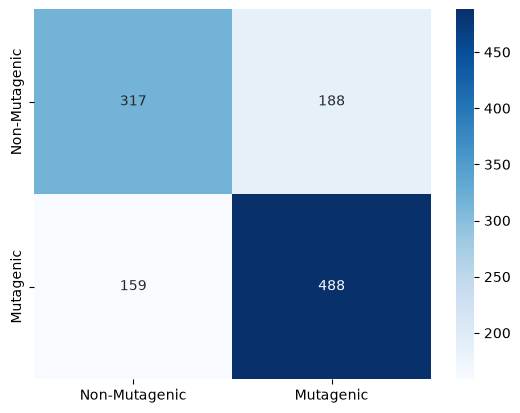

In [26]:
# Using seaborn to plot the confusion matrix
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Mutagenic', 'Mutagenic'], yticklabels=['Non-Mutagenic', 'Mutagenic'])

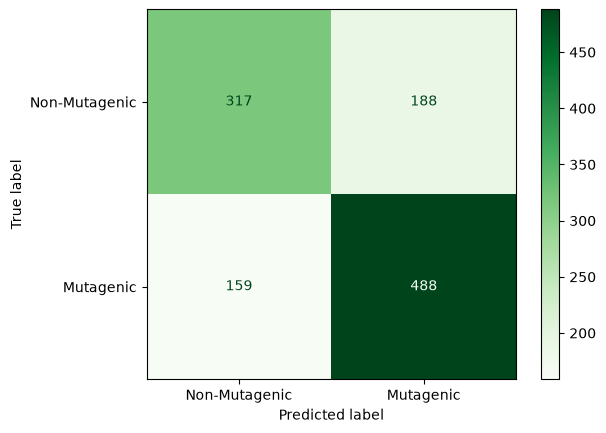

In [27]:
# Using ConfusionMatrixDisplay to plot the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Mutagenic', 'Mutagenic'])
display.plot(cmap='Greens')

In [28]:
# Display the classification report
print(classification_report(y_test, y_pred_knn, target_names=['Non-Mutagenic', 'Mutagenic']))

               precision    recall  f1-score   support

Non-Mutagenic       0.67      0.63      0.65       505
    Mutagenic       0.72      0.75      0.74       647

     accuracy                           0.70      1152
    macro avg       0.69      0.69      0.69      1152
 weighted avg       0.70      0.70      0.70      1152



Accuracy:   0.8            
Precision:  0.817          
Recall:     0.832          
F1:         0.824          


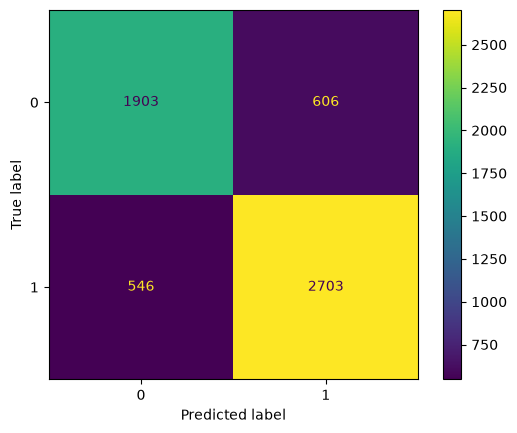

In [29]:
# Now, let's compare against the VEGA model. 
y_clean = clean_df['Experimental value'].astype(int)
y_vega_clean = clean_df['Predicted value'].astype(int)

cm = confusion_matrix(y_clean, y_vega_clean)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
print('{:<10}  {:<15.3}'.format('Accuracy:', accuracy_score(y_clean, y_vega_clean)))
print('{:<10}  {:<15.3f}'.format('Precision:', precision_score(y_clean, y_vega_clean)))
print('{:<10}  {:<15.3f}'.format('Recall:', recall_score(y_clean, y_vega_clean)))
print('{:<10}  {:<15.3f}'.format('F1:', f1_score(y_clean, y_vega_clean)))

In [30]:
# Leave One Out Cross Validation (LOOCV) is a special case of k-fold cross-validation where k is equal to the number of samples in the dataset. 
# In LOOCV, we use one sample as the validation set and the remaining samples as the training set.
# This process is repeated for each sample in the dataset, and the performance metrics are averaged over all iterations.
# This process is used in VEGA

from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
print('Number of folds: ', loo.get_n_splits(X))

Number of folds:  5758


In [31]:
y_pred_loo = np.zeros(y.shape[0])
knn = KNeighborsClassifier(n_neighbors=3)
# Starting the loop
for i, (train_index, test_index) in enumerate(loo.split(X)):
    # Get training data for the current fold
    X_train_loo = X.iloc[train_index]
    y_train_loo = y.iloc[train_index]

    # Get test data for the current fold
    X_test_loo = X.iloc[test_index]

    # Train kNN
    scaler_loo = StandardScaler()
    X_train_loo_scaled = scaler_loo.fit_transform(X_train_loo)
    X_test_loo_scaled = scaler_loo.transform(X_test_loo)

    knn.fit(X_train_loo_scaled, y_train_loo)

    # Predict
    y_pred_loo_knn = knn.predict(X_test_loo_scaled)

    #Soring the prediction in y_pred_loo
    y_pred_loo[i] = y_pred_loo_knn[0]

In [32]:
print(np.unique(y_pred_loo))   # should be [0. 1.]
print(y_pred_loo.mean())       # roughly 0.5 to 0.6

[0. 1.]
0.5850989927058007


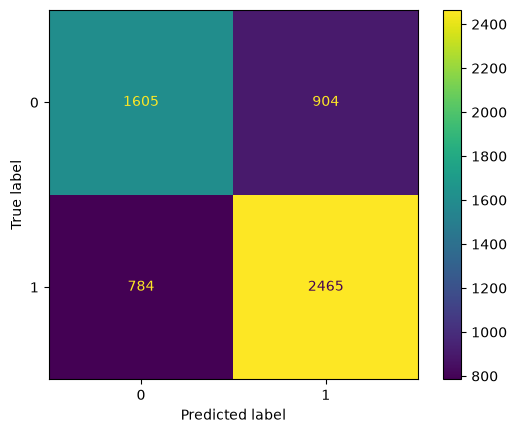

In [33]:
# Confusion matrix
cm_loo = confusion_matrix(y_clean, y_pred_loo)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_loo)
disp.plot()

In [34]:
accuracy_loo = accuracy_score(y_clean, y_pred_loo)
f1_loo = f1_score(y_clean, y_pred_loo)
precision_loo = precision_score(y_clean, y_pred_loo)
recall_loo = recall_score(y_clean, y_pred_loo)

print(f"Accuracy : {accuracy_loo:.3f}")
print(f"f1_score: {f1_loo:.3f}")
print(f"precision: {precision_loo:.3f}")
print(f"Recall: {recall_loo:.3f}")

Accuracy : 0.707
f1_score: 0.745
precision: 0.732
Recall: 0.759


In [48]:
# Do not disturb the previous 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
import numpy as np
from tqdm.notebook import tqdm

num_ks = np.arange(1, 100, 2).astype(int)


X_train_hyp, X_valid, y_train_hyp, y_valid = train_test_split(X_train, y_train, test_size=0.1, random_state=42)
scaler_hyp = StandardScaler()
X_train_hyp_scaled = scaler_hyp.fit_transform(X_train_hyp)
X_valid_scaled = scaler_hyp.transform(X_valid)


train_error = []
valid_error = []

for i in tqdm(range(len(num_ks))):
  knn = KNeighborsClassifier(n_neighbors=num_ks[i])
  knn.fit(X_train_hyp_scaled, y_train_hyp)

  pred_train = knn.predict(X_train_hyp_scaled)
  pred_valid  = knn.predict(X_valid_scaled)

  train_error.append(1-accuracy_score(y_train_hyp, pred_train))
  valid_error.append(1-accuracy_score(y_valid, pred_valid))

  0%|          | 0/50 [00:00<?, ?it/s]

In [43]:
print(len(num_ks), len(train_error), len(valid_error))
print(train_error[:5])

50 50 50
[0.0021712907117008573, 0.16019300361881783, 0.19710494571773218, 0.21544028950542826, 0.22533172496984322]


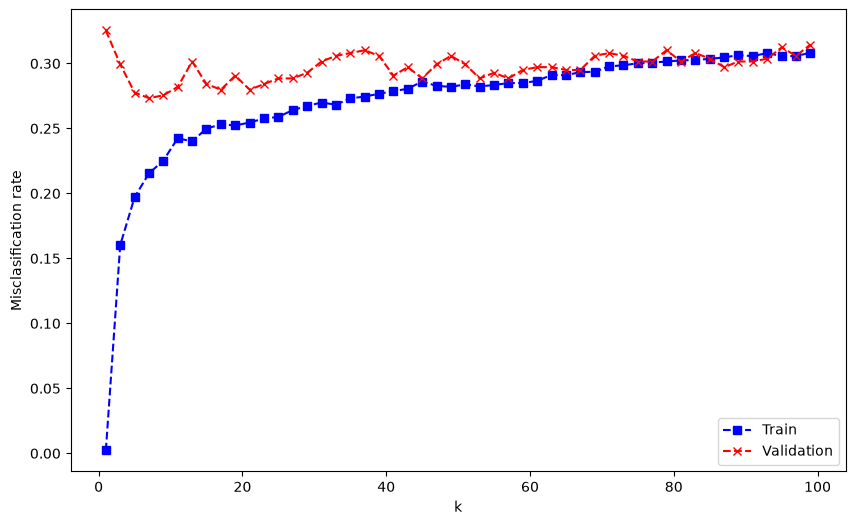

In [44]:
plt.figure(figsize=(10,6))
plt.plot(num_ks, train_error, 'bs--', label='Train')
plt.plot(num_ks, valid_error, 'rx--', label='Validation')
plt.xlabel('k')
plt.ylabel('Misclasification rate')
plt.legend()
plt.show()

In [ ]:
# Cross-validation. Scaling and fit should be done inside the loop to avoid data leakage
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

num_ks = np.arange(1, 50, 1).astype(int)

train_misclassification = []
valid_misclassification = []
for i in tqdm(range(len(num_ks))):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=num_ks[i]))
    ])
    cv_dict = cross_validate(pipe, X_train, y_train, cv=10,
                              scoring='accuracy', return_train_score=True)
  
    k_fold_train_scored = cv_dict['train_score']
    k_fold_valid_scored = cv_dict['test_score']
  
    train_misclassification.append(1-k_fold_train_scored.mean())
    valid_misclassification.append(1-k_fold_valid_scored.mean())
  

  0%|          | 0/49 [00:00<?, ?it/s]

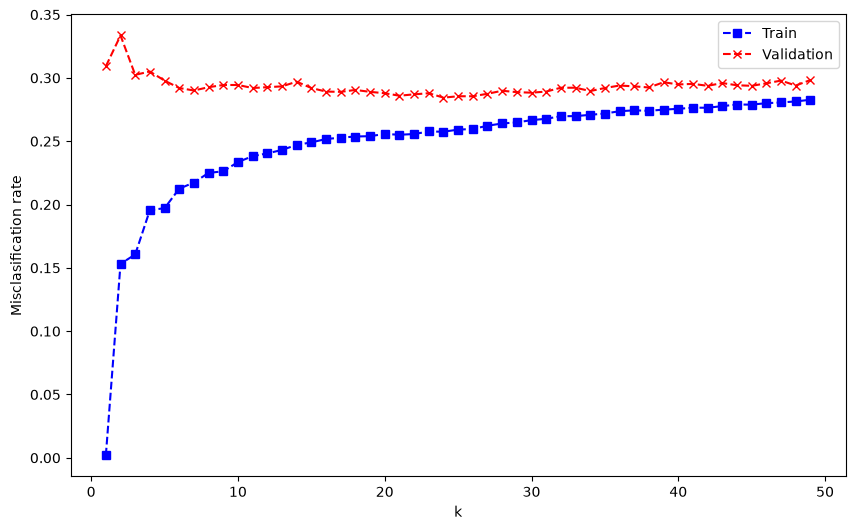

In [52]:
plt.figure(figsize=(10,6))
plt.plot(num_ks, train_misclassification, 'bs--', label='Train')
plt.plot(num_ks, valid_misclassification, 'rx--', label='Validation')
plt.xlabel('k')
plt.ylabel('Misclasification rate')
plt.legend()
plt.show()

Important note: Validation error is nearly flat. Incresing the number of K will have very less impact on the model.

In [53]:
print('k with minimum validation misclassification: ', num_ks[np.argmin(valid_misclassification)])

k with minimum validation misclassification:  24


In [54]:
# ReRunning the LOO with k = 24
y_pred_loo = np.zeros(y.shape[0])
knn = KNeighborsClassifier(n_neighbors=24)
# Starting the loop
for i, (train_index, test_index) in enumerate(loo.split(X)):
    # Get training data for the current fold
    X_train_loo = X.iloc[train_index]
    y_train_loo = y.iloc[train_index]

    # Get test data for the current fold
    X_test_loo = X.iloc[test_index]

    # Train kNN
    scaler_loo = StandardScaler()
    X_train_loo_scaled = scaler_loo.fit_transform(X_train_loo)
    X_test_loo_scaled = scaler_loo.transform(X_test_loo)

    knn.fit(X_train_loo_scaled, y_train_loo)

    # Predict
    y_pred_loo_knn = knn.predict(X_test_loo_scaled)

    #Soring the prediction in y_pred_loo
    y_pred_loo[i] = y_pred_loo_knn[0]

print(np.unique(y_pred_loo))   # should be [0. 1.]
print(y_pred_loo.mean())       # roughly 0.5 to 0.6    


[0. 1.]
0.5833622785689475


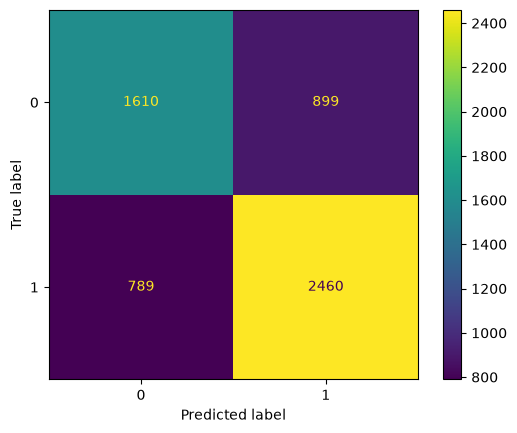

In [55]:
cm_loo = confusion_matrix(y_clean, y_pred_loo)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_loo)
disp.plot()

In [56]:
accuracy_loo = accuracy_score(y_clean, y_pred_loo)
f1_loo = f1_score(y_clean, y_pred_loo)
precision_loo = precision_score(y_clean, y_pred_loo)
recall_loo = recall_score(y_clean, y_pred_loo)

print(f"Accuracy : {accuracy_loo:.3f}")
print(f"f1_score: {f1_loo:.3f}")
print(f"precision: {precision_loo:.3f}")
print(f"Recall: {recall_loo:.3f}")

Accuracy : 0.707
f1_score: 0.745
precision: 0.732
Recall: 0.757
